#  Livrable 2 - Traitement d'images

## Introduction

Le but est de traiter un ensemble de photographies afin de les rendres traitables par les algorithmes de machine learning. Le traitement à réaliser est une operation de débruitage.Nous allons dans ce notebook Jupyter expliquant ces étapes de prétraitement et de performances. Ces algorithmes s'appuieront sur les auto-encodeurs à convolution et les appliqueront pour améliorer la qualité de l'image.

## Définition Auto-encodeur convolutif

Une image en noir et blanc est un ensemble de pixels , ou chaque pixel est représenté par un nombre compris ebtre 0 et 255.

La convolution est une opération mathématique linéaire qui combine deux matrices (une image d'entrée et un filtre, ou noyau) pour générer une nouvelle matrice appelée "carte de caractéristiques" (feature map). Elle consiste à faire glisser le filtre sur toute la surface de l'image et à calculer, à chaque position, la somme des produits terme à terme entre les coefficients du filtre et les pixels de la zone d'image survolée.

Le but principal de l'opération de convolution sur une image est d'extraire automatiquement les caractéristiques (ou motifs) les plus importantes d'une image, tout en réduisant la complexité des données à traiter.

Plutôt que de forcer un ordinateur à analyser des millions de pixels bruts d'un coup, la convolution lui permet de "comprendre" l'image par étapes, du plus simple au plus complexe.

Ici on va utiliser les opérations de convolution dans un réseau de neuronnes. Plus précisément , on va utiliser un auto-encodeur pour reduire les dimension et rendre plus compact les images mais aussi pour réduire du bruit d'image en utilisant les opératios de convolution. Pourquoi parceque 

Tout simplement parce qu’une image contient beaucoup, mais alors beaucoup de données en entrée. Imaginons avec une petite image de 100×100 pixels en couleurs … delà nous fait déjà 100x100x3 donc 30 000 données à envoyer dans le réseau de neurones (et c’est une petite image!). Si nous commencons à empiler couches et neurones, très vite le nombre de paramètres de notre réseau va exploser et le nombre de calculs va croitre de manière exponentielle … de quoi mettre par terre votre machine !

Il faux donc trouver une autre approche que celle classique des réseaux ANN (ou Perceptron Multicouches). L’idée derrière les filtres a convolution est qu’ils permettent de trouver des patterns, des formes dans les images (rappelez vous l’article précédent qui permettait de trouver les contours par exemple). Les CNN permettent en effet de déterminer de manière progressive les différentes formes puis de les assembler pour en trouver d’autres.

L’exemple classique est que les premières couches d’un tel réseau trouve les formes de base d’un visage: les traits principaux, puis on va détecteur les premières formes: nez, bouche, yeux, etc., puis pour finir le visage et pourquoi par reconnaître la personne, etc.

Finalement, un auto-encodeur convolutif n'est qu'une variante de CNN. Vous vous souvenez comment fonction un CNN ? Comment ça s'appliquerait à une image ?
<blockquote> Un CNN applique généralement 3 types d’opérations différentes à une image afin d’en extraire les informations pertinentes.

Ces 3 types d’opérations sont les suivantes :
* La convolution → extraction de motifs
* Le pooling → filtre les infos utiles
* La fonction d’activation de type ReLU → réduit la taille
</blockquote>

## Dataset

In [174]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import pathlib
from tabulate import tabulate

###  Constates


In [175]:
DATA_DIR = pathlib.Path("../../datasets/livrable1")
IMAGE_HEIGHT = 180
IMAGE_WIDTH = 180
BATCH_SIZE = 16
NB_EPOCHS = 20
SEED = 42

### Traitement

### Suppression des images corrompues

Certaines images du dataset sont corrompues et ne peuvent pas être lues par les fonctions de traitement d'images ce qui génère une erreur lors de l'exécution du code et bloque l'entraînement.
Il est donc nécessaire de supprimer ces images.

In [176]:
# Suppression des images corrompues
num_skipped = 0

for image in DATA_DIR.glob("*/*.*"):
    try:
        img = PIL.Image.open(image)
        img.verify()

        img_bytes = tf.io.read_file(str(image))
        decoded_img = tf.io.decode_image(img_bytes)
    except (IOError, SyntaxError, tf.errors.InvalidArgumentError) as e:
        print("Suppression de l'image corrompue : ", image)
        num_skipped += 1
        image.unlink()

print(f"Nombre d'images corrompues supprimées : {num_skipped}")

W0000 00:00:1779804142.277859    5121 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


Nombre d'images corrompues supprimées : 0


### Conversion des PNG en JPEG

In [177]:
# Conversion des PNG en JPEG
for image in DATA_DIR.glob("*/*.png"):
    try:
        img = PIL.Image.open(image)
        rgb_img = img.convert("RGB")
        new_image_path = image.with_suffix(".jpg")
        rgb_img.save(new_image_path, "JPEG")
        image.unlink()
    except (IOError, SyntaxError) as e:
        print("Erreur lors de la conversion de l'image : ", image)

## Pré-analyse

In [178]:
print("Nombre d'image : ", len(list(DATA_DIR.glob("*/*.jpg"))))

Nombre d'image :  33516


Afficher le nombre d'image pour chaque classe (sous-dossier) dans le dataset afin de vérifier que l'entraînement ne sera pas biaisé par un déséquilibre entre les classes.

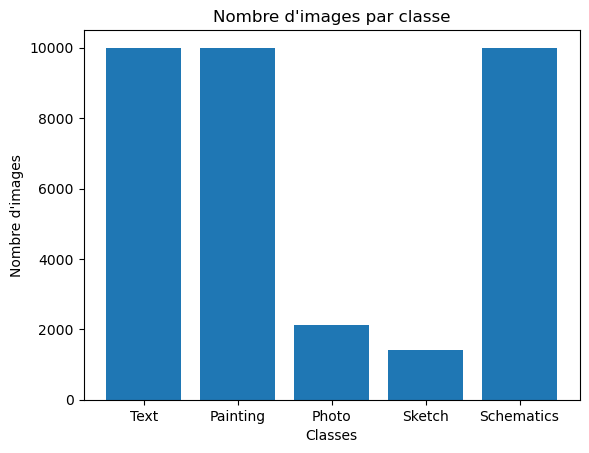

In [179]:
categories = {}

for cat in DATA_DIR.iterdir():
    if cat.is_dir():
        categories[cat.name] = len(list(cat.glob("*.*")))

plt.bar(categories.keys(), categories.values())
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")
plt.title("Nombre d'images par classe")
plt.show()

### Création de dataset
Création de deux datasets. Un d'entraînement qui contient 80% des images étant utilisées pour entraîner le modèle. Le second dataset, de validation, contient les 20% d'images restantes et est utilisé pour évaluer les performances du modèle pendant l'entraînement.

In [180]:
# Le train_set et validation
[train_set, test_set] = tf.keras.preprocessing.image_dataset_from_directory(
  DATA_DIR,
  labels='inferred',
  validation_split=0.2,
  subset ="both",
  seed=SEED,
  image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
  batch_size=BATCH_SIZE
)

Found 33516 files belonging to 5 classes.
Using 26813 files for training.
Using 6703 files for validation.


###  Visualisation des données 

['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


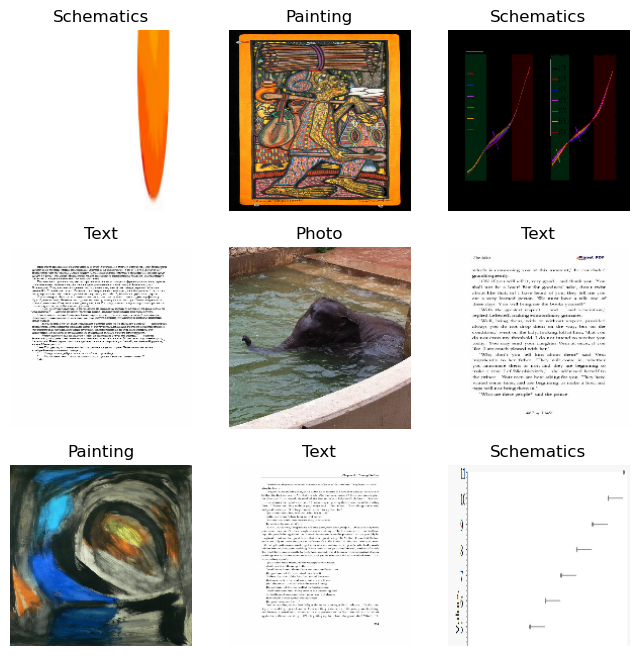

In [181]:
class_names = train_set.class_names
print(class_names)

plt.figure(figsize=(8, 8))
for images, labels in train_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

### Data pre-processing 

#### Normalisation

In [182]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_set = train_set.map(lambda x, y: (normalization_layer(x), y))
test_set  = test_set.map(lambda x, y: (normalization_layer(x), y))

In [183]:
for images, labels in train_set.take(1):
    print(images.shape)

(16, 180, 180, 3)


In [184]:
# ✅ Data CLEAN (déjà normalisée)
train_set_clean = train_set
test_set_clean  = test_set

# 🔊 Data BRUITÉE
noise_factor = 0.5

def add_noise(images):
    noise = tf.random.normal(shape=tf.shape(images), mean=0.0, stddev=noise_factor)
    noisy_images = images + noise
    noisy_images = tf.clip_by_value(noisy_images, 0.0, 1.0)
    return noisy_images

train_set_noisy = train_set.map(lambda x, y: (add_noise(x), y))
test_set_noisy  = test_set.map(lambda x, y: (add_noise(x), y))

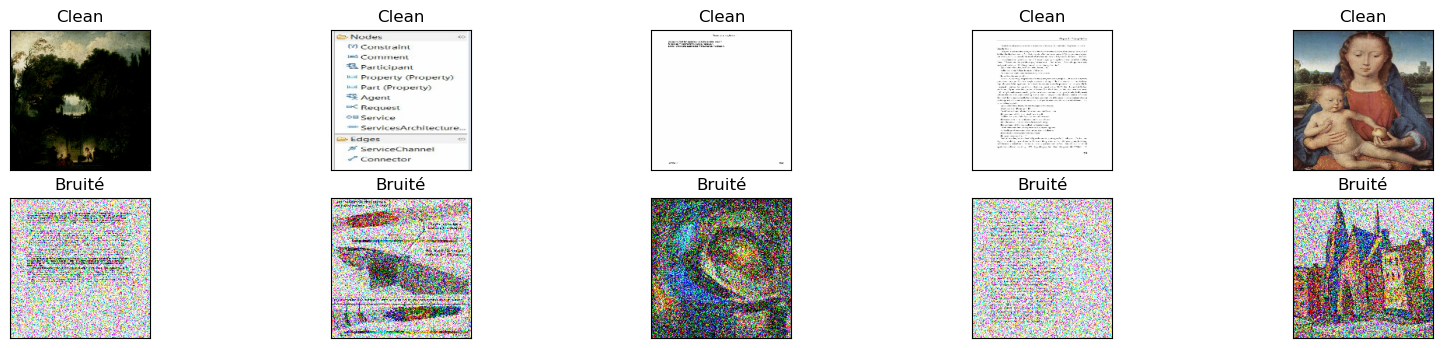

In [185]:
import matplotlib.pyplot as plt

def display_images(dataset_clean, dataset_noisy, n=5):
    plt.figure(figsize=(20, 4))
    
    for (images_clean, _) in dataset_clean.take(1):
        for (images_noisy, _) in dataset_noisy.take(1):
            
            for i in range(n):
                # Ligne 1 : Clean
                ax = plt.subplot(2, n, i + 1)
                plt.imshow(images_clean[i].numpy())
                plt.title("Clean")
                ax.get_xaxis().set_visible(False)
                ax.get_yaxis().set_visible(False)

                # Ligne 2 : Bruité
                ax = plt.subplot(2, n, i + 1 + n)
                plt.imshow(images_noisy[i].numpy())
                plt.title("Bruité")
                ax.get_xaxis().set_visible(False)
                ax.get_yaxis().set_visible(False)

    plt.show()

# Appel
display_images(train_set_clean, train_set_noisy, n=5)

#### Bruitage

### Configurations principales de nos modèles

In [186]:
# Configurations principales de nos modèles
IMG_SIZE          = 180                # taille coté final d'une image en pixel (ici 28x28)
NB_EPOCHS_DENOISE = 10               # nombre epoch alogithme debruiter
BATCH_SIZE        = 128               # taille batch de traitement
SAV_MODEL_DENOISE = "denoiser.h5"     # sauvegarde du modele de debruitage

Il faut maintenant écrire un code qui permet d'encoder une image en utilisant trois couches de convolution.

*Tip* : Utiliser la classe Input, Conv2D, MaxPooling2D et UpSampling2D

In [187]:
from keras.layers import Input, Conv2D, MaxPooling2D

# Input
input_img = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

# Conv1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

# Conv2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

Passon au décodeur. Écrivez un code qui permet de décoder une image encodée selon l'architecture du réseau de neurones décrite auparavent. 

In [188]:
from keras.layers import UpSampling2D, Conv2D
# DeConv1
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

# DeConv2
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

# DeConv3 (output)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

In [189]:
from tensorflow.keras.models import Model

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adadelta',
                    loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 180, 180, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 180, 180, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 45, 45, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 90, 90, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 180, 180, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 180, 180, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [190]:
import tensorflow as tf

def to_grayscale(images):
    return tf.image.rgb_to_grayscale(images)  # (180, 180, 3) -> (180, 180, 1)

train_clean_images = train_set_clean.map(lambda x, y: to_grayscale(x))
test_clean_images  = test_set_clean.map(lambda x, y: to_grayscale(x))

train_noisy_images = train_set_noisy.map(lambda x, y: to_grayscale(x))
test_noisy_images  = test_set_noisy.map(lambda x, y: to_grayscale(x))

train_set_denoising = tf.data.Dataset.zip((train_noisy_images, train_clean_images))
test_set_denoising  = tf.data.Dataset.zip((test_noisy_images, test_clean_images))

In [ ]:
history = autoencoder.fit(
    train_set_denoising,
    epochs=NB_EPOCHS_DENOISE,
    validation_data=test_set_denoising,
    callbacks=[tf.keras.callbacks.TensorBoard(
        log_dir='/tmp/tb',
        histogram_freq=0,
        write_graph=False
    )]
)

# ============================================================
# 7. SAUVEGARDE
# ============================================================
autoencoder.save(SAV_MODEL_DENOISE)
print(f"Modèle sauvegardé : {SAV_MODEL_DENOISE}")

Epoch 1/10
